# minimal-zoom-fft 3/3: Benchmark

*Speed against zero-padded FFTs and SciPy, accuracy against float64 summation, memory, and where the limits are.*

Series: [1. Why](01_why_zoom_fft.ipynb) · [2. What it computes](02_what_it_computes.ipynb) · [3. Benchmark](03_benchmark.ipynb)

All timings come from one machine and one process, with other software running. They show how the cost scales, not portable constants, and differences below about 20 percent are noise. `bench` makes one warm-up call, then takes the minimum of `repeats` timed calls; on MPS every call is bracketed with `torch.mps.synchronize()`. In the figures blue is `torch.fft`, orange is the zero-padded route, aqua is `zoom_fft` and pink marks single precision.

In [1]:
import math, os, platform, time
import numpy as np
import torch
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from minimal_zoom_fft import zoom_fft, zoom_ifft, zoom_freq, czt

plt.rcParams.update({
    "figure.dpi": 110, "figure.figsize": (9, 3.2),
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "lines.linewidth": 1.5,
    "axes.titlesize": 9.5, "image.cmap": "gray",
})
torch.manual_seed(0)

PI = math.pi
C64, C128 = torch.complex64, torch.complex128
BLUE, ORANGE, AQUA, PINK = "#2a78d6", "#eb6834", "#1baf7a", "#e87ba4"
MB = 1 << 20

def bench(fn, repeats=5):
    # one warm-up call, then the minimum of `repeats` timed calls, in seconds
    out = fn()
    on_mps = torch.is_tensor(out) and out.device.type == "mps"
    if on_mps:
        torch.mps.synchronize()
    times = []
    for _ in range(repeats):
        t0 = time.perf_counter()
        fn()
        if on_mps:
            torch.mps.synchronize()
        times.append(time.perf_counter() - t0)
    return min(times)

def l_fft(n_in, n_out):
    # the Bluestein FFT length: the power of two >= n_in + n_out - 1
    return 1 << (n_in + n_out - 2).bit_length()

MPS = torch.backends.mps.is_available()
print(f"torch {torch.__version__}   numpy {np.__version__}   scipy {__import__('scipy').__version__}")
print(f"{platform.processor()} / {platform.machine()}, {os.cpu_count()} logical cores, "
      f"{torch.get_num_threads()} torch threads, MPS {MPS}")

torch 2.14.0   numpy 2.4.6   scipy 1.17.1
arm / arm64, 8 logical cores, 4 torch threads, MPS True


## 1. Speed

To sample the spectrum $z$ times finer than the FFT grid, the padded route transforms an $L \times L$ array with $L = zN$ and keeps an $M \times M$ block. The zoomed route runs, on each axis, three FFTs of length $L_\mathrm{fft} = \mathrm{nextpow2}(N + M - 1)$ over rows of length $\max(N, M)$, whatever $z$ is. The figure draws the arrays each route allocates for the $256 \times 256$ pupil to $256 \times 256$ PSF case of notebook 1, to scale.

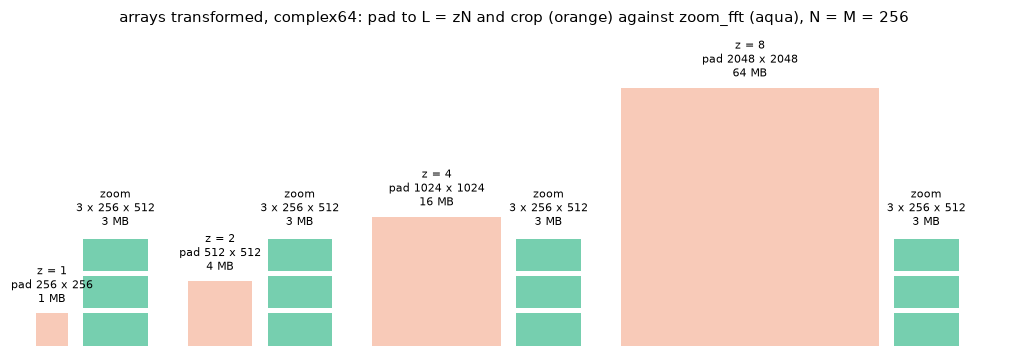

In [2]:
N_PUPIL = M_PSF = 256
LF = l_fft(N_PUPIL, M_PSF)

fig, ax = plt.subplots(figsize=(11, 3.4))
x0 = 0
for z in (1, 2, 4, 8):
    L = z * N_PUPIL
    ax.add_patch(Rectangle((x0, 0), L, L, fc=ORANGE, ec="none", alpha=0.35))
    ax.text(x0 + L / 2, L + 60, f"z = {z}\npad {L} x {L}\n{2 * L * L * 8 / MB:.0f} MB", ha="center", va="bottom", fontsize=7.5)
    x0 += L + 120
    for i in range(3):
        ax.add_patch(Rectangle((x0, i * (N_PUPIL + 40)), LF, N_PUPIL, fc=AQUA, ec="none", alpha=0.6))
    ax.text(x0 + LF / 2, 3 * (N_PUPIL + 40) + 40, f"zoom\n3 x {N_PUPIL} x {LF}\n{3 * N_PUPIL * LF * 8 / MB:.0f} MB",
            ha="center", va="bottom", fontsize=7.5)
    x0 += LF + 320
ax.set(xlim=(-50, x0), ylim=(-50, 8 * N_PUPIL + 450), xticks=[], yticks=[], aspect="equal",
       title=f"arrays transformed, complex64: pad to L = zN and crop (orange) against zoom_fft (aqua), N = M = {N_PUPIL}")
ax.grid(False)
for s in ax.spines.values():
    s.set_visible(False)
fig.tight_layout()

Two measurements. First the full band with $M = N$ in 1-D, where `zoom_fft` returns what `torch.fft.fft` returns with three FFTs of length $2N$ instead of one of length $N$, so the ratio should be six plus the cost of building the chirp. Then the pupil-to-PSF case by both routes, checked against each other in complex128 before being timed.

1-D, full band, M = N, complex64
      N   L_fft     zoom_fft    torch.fft   ratio
    256     512     0.084 ms     0.004 ms   20.68
    512    1024     0.098 ms     0.006 ms   17.31
   1024    2048     0.132 ms     0.009 ms   14.30
   2048    4096     0.197 ms     0.017 ms   11.47
   4096    8192     0.372 ms     0.033 ms   11.25


   8192   16384     1.001 ms     0.068 ms   14.71
  16384   32768     2.191 ms     0.261 ms    8.40
  32768   65536     3.597 ms     0.452 ms    7.96


  65536  131072    10.764 ms     0.835 ms   12.89

2-D, 256 x 256 pupil to 256 x 256 PSF, complex64; at z = 8 the routes agree to 1.2e-14 in complex128
  z      L      padded      zoomed  speed-up   pad mem  zoom mem
  1    256     0.41 ms     1.81 ms      0.23      1 MB      3 MB


  2    512     1.83 ms     1.91 ms      0.96      4 MB      3 MB
  4   1024    11.85 ms     1.82 ms      6.52     16 MB      3 MB


  8   2048    60.08 ms     1.80 ms     33.31     64 MB      3 MB


 16   4096   281.44 ms     2.15 ms    130.76    256 MB      3 MB


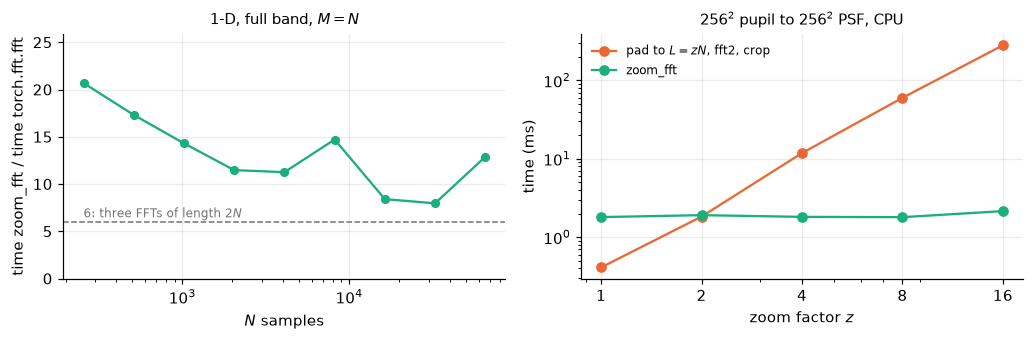

In [3]:
sizes_1d = [1 << p for p in range(8, 17)]
t_zoom_1d, t_fft_1d = [], []
print("1-D, full band, M = N, complex64")
print(f"{'N':>7} {'L_fft':>7} {'zoom_fft':>12} {'torch.fft':>12} {'ratio':>7}")
for n in sizes_1d:
    x = torch.randn(n, dtype=C64)
    t_zoom_1d.append(bench(lambda: zoom_fft(x), repeats=15))
    t_fft_1d.append(bench(lambda: torch.fft.fft(x, norm="ortho"), repeats=15))
    print(f"{n:>7} {l_fft(n, n):>7} {t_zoom_1d[-1]*1e3:>9.3f} ms {t_fft_1d[-1]*1e3:>9.3f} ms {t_zoom_1d[-1]/t_fft_1d[-1]:>7.2f}")

def padded_psf(pupil, z, dtype=C64):
    # fft2 of the zero-padded pupil, cropped to the central M x M block
    n = pupil.shape[-1]
    L = z * n
    big = torch.zeros(L, L, dtype=dtype)
    big[:n, :n] = pupil
    big = torch.roll(big, (-(n // 2), -(n // 2)), (0, 1))       # origin at index n // 2
    S = torch.fft.fftshift(torch.fft.fft2(big))
    o = L // 2 - M_PSF // 2
    return S[o:o + M_PSF, o:o + M_PSF]

def zoomed_psf(pupil, z):
    L = z * pupil.shape[-1]
    return zoom_fft(pupil, (M_PSF, M_PSF), -PI * M_PSF / L, PI * M_PSF / L, dim=(-2, -1), norm="backward", center=True)

p128 = torch.randn(N_PUPIL, N_PUPIL, dtype=C128)
a, b = padded_psf(p128, 8, C128), zoomed_psf(p128, 8)
print(f"\n2-D, {N_PUPIL} x {N_PUPIL} pupil to {M_PSF} x {M_PSF} PSF, complex64; "
      f"at z = 8 the routes agree to {(a - b).abs().max().item() / a.abs().max().item():.1e} in complex128")
pupil = torch.randn(N_PUPIL, N_PUPIL, dtype=C64)
zs = [1, 2, 4, 8, 16]
t_pad_2d, t_zoom_2d = [], []
print(f"{'z':>3} {'L':>6} {'padded':>11} {'zoomed':>11} {'speed-up':>9} {'pad mem':>9} {'zoom mem':>9}")
for z in zs:
    L = z * N_PUPIL
    t_pad_2d.append(bench(lambda: padded_psf(pupil, z), repeats=7))
    t_zoom_2d.append(bench(lambda: zoomed_psf(pupil, z), repeats=15))
    print(f"{z:>3} {L:>6} {t_pad_2d[-1]*1e3:>8.2f} ms {t_zoom_2d[-1]*1e3:>8.2f} ms {t_pad_2d[-1]/t_zoom_2d[-1]:>9.2f} "
          f"{2*L*L*8/MB:>6.0f} MB {3*N_PUPIL*LF*8/MB:>6.0f} MB")

fig, (ax, ax2) = plt.subplots(1, 2, figsize=(9.5, 3.2))
ratio_1d = np.array(t_zoom_1d) / np.array(t_fft_1d)
ax.semilogx(sizes_1d, ratio_1d, "o-", ms=5, color=AQUA)
ax.axhline(6.0, color="0.45", lw=1, ls="--")
ax.text(sizes_1d[0], 6.4, "6: three FFTs of length $2N$", fontsize=8, color="0.45")
ax.set(xlabel="$N$ samples", ylabel="time zoom_fft / time torch.fft.fft", title="1-D, full band, $M = N$", ylim=(0, max(ratio_1d) * 1.25))
ax2.loglog(zs, np.array(t_pad_2d) * 1e3, "o-", ms=6, color=ORANGE, label="pad to $L = zN$, fft2, crop")
ax2.loglog(zs, np.array(t_zoom_2d) * 1e3, "o-", ms=6, color=AQUA, label="zoom_fft")
ax2.set(xlabel="zoom factor $z$", ylabel="time (ms)", title=f"${N_PUPIL}^2$ pupil to ${M_PSF}^2$ PSF, CPU")
ax2.set_xticks(zs, [str(z) for z in zs]); ax2.xaxis.set_minor_formatter(plt.NullFormatter())
ax2.legend(frameon=False, fontsize=8, loc="upper left")
fig.tight_layout()

In this run the 1-D ratio lies between about 8 and 21. It stays above the six of the three FFTs at every size and is largest for the smallest $N$, where the chirps and the fixed cost of the call weigh most: on a full band `torch.fft` is the cheaper call. In 2-D the zoomed time is flat in $z$, within the noise, while the padded route grows as $z^2 \log z$ in time and $z^2$ in memory; the crossover sits near $z = 2$, where the two are within noise of each other, and at $z = 16$ the padded route is about two orders of magnitude slower.

## 2. SciPy, MPS, batching, and the power-of-two step

`scipy.signal.zoom_fft` is the same algorithm on NumPy, one axis at a time; with `fs=2*pi` its band is in radians per sample and it matches `zoom_fft` with `norm="backward"`. The other panels: the same code on the Metal backend, in float32 only, and the cost of $L_\mathrm{fft}$, which doubles when $N + M - 1$ crosses a power of two.

zoom_fft vs scipy.signal.zoom_fft, complex64: 4.0e-07    czt vs scipy.signal.czt, complex128: 8.6e-12


zoom_fft / scipy time, 1-D: 0.82 to 1.21;  2-D 256^2 z = 4: CPU 1.87 ms, MPS 3.06 ms; 1024^2: CPU 32.1 ms, MPS 7.3 ms
power-of-two step, batch of 32: 0.32 ms at N = M = 512, 0.56 ms at 544
batching, 128^2 -> 256^2: 1.47 ms for one transform, 1.67 ms per transform in a batch of 64
MPS vs CPU at 512^2, z = 4: agree to 1e-06; complex128 on MPS: TypeError, Cannot convert a MPS Tensor to float64 dtype as the MPS framework doesn't support float64


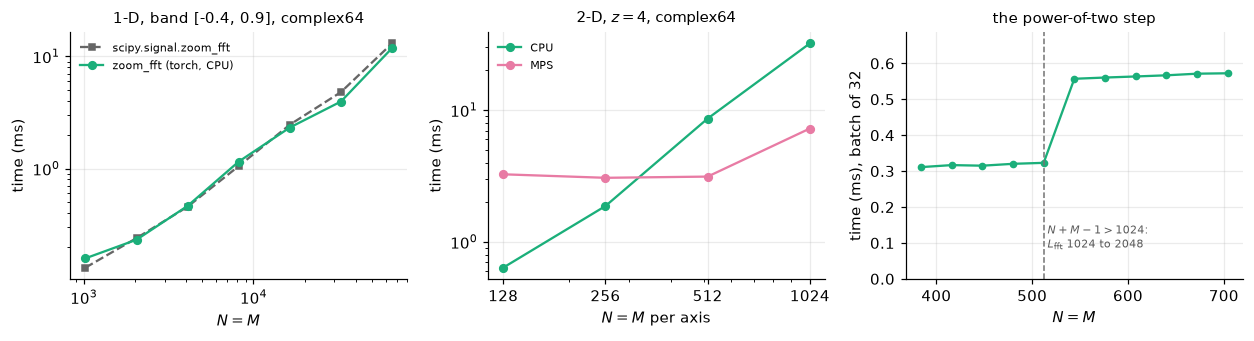

In [4]:
from scipy.signal import czt as scipy_czt, zoom_fft as scipy_zoom_fft

k0, k1 = -0.4, 0.9
rng = np.random.default_rng(0)
xn = (rng.standard_normal(1024) + 1j * rng.standard_normal(1024)).astype(np.complex64)
ref_s = scipy_zoom_fft(xn, [k0, k1], 1024, fs=2 * PI)
ref_c = scipy_czt(xn.astype(np.complex128), 400, w=np.exp(-0.013j), a=np.exp(0.31j))
print(f"zoom_fft vs scipy.signal.zoom_fft, complex64: "
      f"{np.abs(zoom_fft(torch.from_numpy(xn), 1024, k0, k1, norm='backward').numpy() - ref_s).max() / np.abs(ref_s).max():.1e}"
      f"    czt vs scipy.signal.czt, complex128: "
      f"{np.abs(czt(torch.from_numpy(xn).to(C128), 400, -0.013, 0.31).numpy() - ref_c).max() / np.abs(ref_c).max():.1e}")

sizes_s = [1 << p for p in range(10, 17)]
t_scipy, t_torch = [], []
for n in sizes_s:
    a = (rng.standard_normal(n) + 1j * rng.standard_normal(n)).astype(np.complex64)
    b = torch.from_numpy(a)
    t_scipy.append(bench(lambda: scipy_zoom_fft(a, [k0, k1], n, fs=2 * PI), repeats=9))
    t_torch.append(bench(lambda: zoom_fft(b, n, k0, k1, norm="backward"), repeats=9))

sizes_m = [128, 256, 512, 1024]
t_cpu, t_mps = [], []
for n in sizes_m:
    xc = torch.randn(n, n, dtype=C64)
    run = lambda t, n=n: zoom_fft(t, (n, n), -PI / 4, PI / 4, dim=(-2, -1), center=True)
    t_cpu.append(bench(lambda: run(xc), repeats=7))
    if MPS:
        xm = xc.to("mps")
        t_mps.append(bench(lambda: run(xm), repeats=7))
        if n == 512:
            e_mps = (run(xc) - run(xm).cpu()).abs().max().item() / run(xc).abs().max().item()

sizes_c = list(range(384, 705, 32))
t_cliff = []
for n in sizes_c:
    xs = torch.randn(32, n, dtype=C64)
    t_cliff.append(bench(lambda: zoom_fft(xs, n, k0, k1), repeats=9))

xb1, xb64 = torch.randn(1, 128, 128, dtype=C64), torch.randn(64, 128, 128, dtype=C64)
zb = lambda t: zoom_fft(t, (256, 256), -0.5, 0.5, dim=(-2, -1), center=True)
t_b1, t_b64 = bench(lambda: zb(xb1), repeats=9), bench(lambda: zb(xb64), repeats=9)
r = np.array(t_torch) / np.array(t_scipy)
print(f"zoom_fft / scipy time, 1-D: {r.min():.2f} to {r.max():.2f};  2-D {sizes_m[1]}^2 z = 4: CPU {t_cpu[1]*1e3:.2f} ms"
      + (f", MPS {t_mps[1]*1e3:.2f} ms; {sizes_m[-1]}^2: CPU {t_cpu[-1]*1e3:.1f} ms, MPS {t_mps[-1]*1e3:.1f} ms" if MPS else ""))
print(f"power-of-two step, batch of 32: {t_cliff[4]*1e3:.2f} ms at N = M = {sizes_c[4]}, {t_cliff[5]*1e3:.2f} ms at {sizes_c[5]}")
print(f"batching, 128^2 -> 256^2: {t_b1*1e3:.2f} ms for one transform, {t_b64/64*1e3:.2f} ms per transform in a batch of 64")
if MPS:
    print(f"MPS vs CPU at 512^2, z = 4: agree to {e_mps:.0e}; complex128 on MPS: ", end="")
    try:
        torch.randn(4, dtype=C128).to("mps"); print("accepted")
    except Exception as e:
        print(f"{type(e).__name__}, {str(e).split('.')[0]}")

fig, axes = plt.subplots(1, 3, figsize=(11.5, 3.2))
ax = axes[0]
ax.loglog(sizes_s, np.array(t_scipy) * 1e3, "s--", ms=4, color="0.4", label="scipy.signal.zoom_fft")
ax.loglog(sizes_s, np.array(t_torch) * 1e3, "o-", ms=5, color=AQUA, label="zoom_fft (torch, CPU)")
ax.set(xlabel="$N = M$", ylabel="time (ms)", title="1-D, band [-0.4, 0.9], complex64"); ax.legend(fontsize=7.5, frameon=False)
ax = axes[1]
ax.loglog(sizes_m, np.array(t_cpu) * 1e3, "o-", ms=5, color=AQUA, label="CPU")
if MPS:
    ax.loglog(sizes_m, np.array(t_mps) * 1e3, "o-", ms=5, color=PINK, label="MPS")
ax.set(xlabel="$N = M$ per axis", ylabel="time (ms)", title="2-D, $z = 4$, complex64")
ax.set_xticks(sizes_m, [str(n) for n in sizes_m]); ax.xaxis.set_minor_formatter(plt.NullFormatter()); ax.legend(fontsize=7.5, frameon=False)
ax = axes[2]
ax.plot(sizes_c, np.array(t_cliff) * 1e3, "o-", ms=4, color=AQUA)
ax.axvline(512.5, color="0.45", lw=1, ls="--")
ax.text(516, max(t_cliff) * 1e3 * 0.15, "$N + M - 1 > 1024$:\n$L_\\mathrm{fft}$ 1024 to 2048", fontsize=7.5, color="0.35")
ax.set(xlabel="$N = M$", ylabel="time (ms), batch of 32", title="the power-of-two step", ylim=(0, max(t_cliff) * 1e3 * 1.2))
fig.tight_layout()

## 3. Accuracy

The reference is the definition summed explicitly in complex128, with the phase $\omega_m n$ reduced modulo $2\pi$ before the cosine and sine, at 64 random output indices. Errors are relative to the largest reference value, and `torch.fft.fft` is measured against the same reference since it has round-off of its own.

Bluestein needs $e^{i w k^2 / 2}$ for $k$ up to $\max(N, M)$. On the full band the largest phase is $\pi N$ radians, about $2 \times 10^5$ at $N = 65536$, where float32 resolves about $10^{-2}$ radians. `core.py` builds the phase in float64, reduces it modulo $2\pi$ and casts afterwards; `naive_zoom_fft` below is the same algorithm with the phase built in float32.

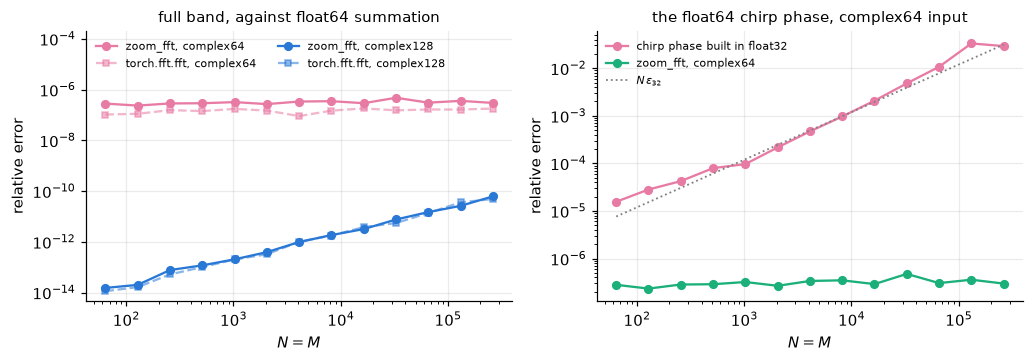

complex64, full band: zoom_fft 2.3e-07 to 4.8e-07, torch.fft.fft 9.0e-08 to 1.8e-07, float32 chirp phase at N = 262144: 2.9e-02

band position and width, N = M = 1024; the last column is the round-off of the reference itself
  k_start      span       step   complex64   complex128   ref floor
      0.0   6.3e+00    6.1e-03    3.65e-07     3.27e-13     1.4e-12
      0.0   1.0e-02    9.8e-06    3.03e-07     7.19e-16     2.3e-15
      0.0   1.0e-06    9.8e-10    5.07e-07     7.23e-16     2.3e-19
   1000.0   6.3e+00    6.1e-03    2.66e-07     4.57e-11     2.3e-10
   1000.0   1.0e-02    9.8e-06    5.95e-07     5.67e-11     2.3e-10
   1000.0   1.0e-06    9.8e-10    4.26e-07     4.87e-11     2.3e-10


In [5]:
gen = torch.Generator().manual_seed(0)
eps32, eps64 = float(np.finfo(np.float32).eps), float(np.finfo(np.float64).eps)

def brute_rows(x, m_idx, n_out, k_start=0.0, k_end=2 * PI, center=0.0):
    # rows m_idx of X[m] = sum_n x[n] exp(-i w_m (n - c)), in complex128
    x = x.to(C128).ravel()
    n = torch.arange(x.numel(), dtype=torch.float64) - center
    out = torch.empty(len(m_idx), dtype=C128)
    for j, wj in enumerate(zoom_freq(n_out, k_start, k_end)[m_idx]):
        phase = torch.remainder(-wj * n, 2 * PI)
        out[j] = (x * torch.complex(torch.cos(phase), torch.sin(phase))).sum()
    return out

def rel_err(got, ref):
    return (got.to(C128) - ref).abs().max().item() / ref.abs().max().item()

def naive_zoom_fft(x, n_out, k_start, k_end):
    # Bluestein with the chirp phase built directly in float32
    n_in = x.shape[-1]
    w, a = -(k_end - k_start) / n_out, k_start
    k = torch.arange(max(n_in, n_out), dtype=torch.float32)
    chirp = torch.exp(1j * (w * k * k / 2))
    pre = chirp[:n_in] * torch.exp(-1j * (a * k[:n_in]))
    kernel = torch.cat([chirp[1:n_in].flip(0), chirp[:n_out]]).conj()
    y = torch.fft.ifft(torch.fft.fft(x * pre, n=l_fft(n_in, n_out)) * torch.fft.fft(kernel, n=l_fft(n_in, n_out)))
    return y[..., n_in - 1:n_in - 1 + n_out] * chirp[:n_out]

err_sizes = [1 << p for p in range(6, 19)]
e_z64, e_f64, e_z128, e_f128, e_naive = [], [], [], [], []
for n in err_sizes:
    x = torch.randn(n, dtype=C128, generator=gen)
    idx = torch.randperm(n, generator=gen)[:64]
    ref = brute_rows(x, idx, n)
    e_z64.append(rel_err(zoom_fft(x.to(C64), norm="backward")[idx], ref))
    e_f64.append(rel_err(torch.fft.fft(x.to(C64))[idx], ref))
    e_z128.append(rel_err(zoom_fft(x, norm="backward")[idx], ref))
    e_f128.append(rel_err(torch.fft.fft(x)[idx], ref))
    e_naive.append(rel_err(naive_zoom_fft(x.to(C64), n, 0.0, 2 * PI)[idx], ref))

fig, (ax, ax2) = plt.subplots(1, 2, figsize=(9.5, 3.4))
ax.loglog(err_sizes, e_z64, "o-", ms=5, color=PINK, label="zoom_fft, complex64")
ax.loglog(err_sizes, e_f64, "s--", ms=4, color=PINK, alpha=0.55, label="torch.fft.fft, complex64")
ax.loglog(err_sizes, e_z128, "o-", ms=5, color=BLUE, label="zoom_fft, complex128")
ax.loglog(err_sizes, e_f128, "s--", ms=4, color=BLUE, alpha=0.55, label="torch.fft.fft, complex128")
ax.set(xlabel="$N = M$", ylabel="relative error", title="full band, against float64 summation", ylim=(None, 2e-4))
ax.legend(frameon=False, fontsize=7, ncols=2, loc="upper left")
ax2.loglog(err_sizes, e_naive, "o-", ms=5, color=PINK, label="chirp phase built in float32")
ax2.loglog(err_sizes, e_z64, "o-", ms=5, color=AQUA, label="zoom_fft, complex64")
ax2.loglog(err_sizes, np.array(err_sizes) * eps32, ":", lw=1.2, color="0.5", label=r"$N\,\varepsilon_{32}$")
ax2.set(xlabel="$N = M$", ylabel="relative error", title="the float64 chirp phase, complex64 input")
ax2.legend(frameon=False, fontsize=7, loc="upper left")
fig.tight_layout()
plt.show()

print(f"complex64, full band: zoom_fft {min(e_z64):.1e} to {max(e_z64):.1e}, torch.fft.fft {min(e_f64):.1e} to {max(e_f64):.1e}, "
      f"float32 chirp phase at N = {err_sizes[-1]}: {e_naive[-1]:.1e}")
n_b = 1024
xb = torch.randn(n_b, dtype=C128, generator=gen)
idx_b = torch.randperm(n_b, generator=gen)[:64]
print(f"\nband position and width, N = M = {n_b}; the last column is the round-off of the reference itself")
print(f"{'k_start':>9} {'span':>9} {'step':>10} {'complex64':>11} {'complex128':>12} {'ref floor':>11}")
for ks in (0.0, 1000.0):
    for span in (2 * PI, 1e-2, 1e-6):
        ref = brute_rows(xb, idx_b, n_b, ks, ks + span)
        print(f"{ks:>9.1f} {span:>9.1e} {span/n_b:>10.1e} "
              f"{rel_err(zoom_fft(xb.to(C64), n_b, ks, ks + span, norm='backward')[idx_b], ref):>11.2e} "
              f"{rel_err(zoom_fft(xb, n_b, ks, ks + span, norm='backward')[idx_b], ref):>12.2e} "
              f"{max(abs(ks), abs(ks + span)) * n_b * eps64:>11.1e}")

In complex64 the error is flat in $N$ and a factor of two to three above `torch.fft.fft`. The complex128 curves rise together with $N$: a float64 sum of $N$ terms accumulates its own round-off, so there the reference is the limiting term. With the chirp phase built in float32 the error follows $N \varepsilon_{32}$, is around one percent at $N = 65536$ in the figure and reaches $2.9 \times 10^{-2}$ at $N = 262144$; the reduction modulo $2\pi$ in float64 is the only difference between the two curves. The band table shows the same complex64 level for a band $10^{-6}$ radians wide starting 1000 radians from the origin, since the frequencies are built in float64 as well.

## 4. Memory, edge cases, and when not to use it

For a 2-D $N \times N \to M \times M$ zoom the implementation holds about three buffers of $\max(N, M) \times L_\mathrm{fft}$ complex samples, independent of the zoom factor, against $2 L^2$ for the padded route. The edge cases below are each checked against the float64 summation or report the exception raised.

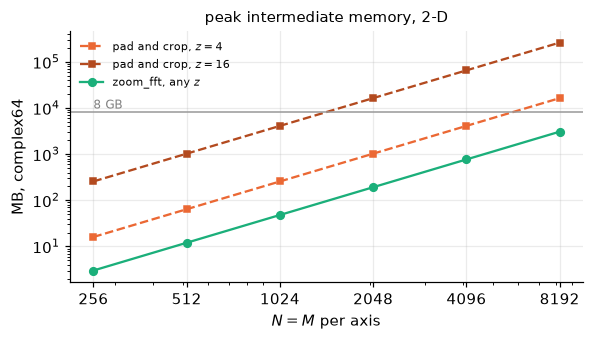

M = 1                                    rel err 6.0e-16
N = 1                                    rel err 3.3e-16
k_end < k_start (negative step)          rel err 3.4e-15
band of width 4 pi (aliases)             rel err 4.4e-14, the two halves agree to 4.1e-14
N = 16, M = 100000                       rel err 2.8e-07, L_fft = 131072, 10.8 ms
real float32 input                       promoted to torch.complex64, no rfft saving
float16 input                            TypeError: unsupported dtype torch.float16; expected float32/64 or complex64/128
n_out = 0                                ValueError: n_out=0 must be at least 1


In [6]:
ns = [256, 512, 1024, 2048, 4096, 8192]
mem_zoom = [3 * n * l_fft(n, n) * 8 / MB for n in ns]
fig, ax = plt.subplots(figsize=(5.5, 3.2))
for z, col in ((4, ORANGE), (16, "#b34a1f")):
    ax.loglog(ns, [2 * (z * n) ** 2 * 8 / MB for n in ns], "s--", ms=4, color=col, label=f"pad and crop, $z = {z}$")
ax.loglog(ns, mem_zoom, "o-", ms=5, color=AQUA, label="zoom_fft, any $z$")
ax.axhline(8 * 1024, color="0.6", lw=1); ax.text(ns[0], 9.5 * 1024, "8 GB", fontsize=8, color="0.5")
ax.set(xlabel="$N = M$ per axis", ylabel="MB, complex64", title="peak intermediate memory, 2-D")
ax.set_xticks(ns, [str(n) for n in ns]); ax.xaxis.set_minor_formatter(plt.NullFormatter())
ax.legend(fontsize=7.5, frameon=False)
fig.tight_layout()
plt.show()

def case(name, fn):
    try:
        print(f"{name:<40} {fn()}")
    except Exception as e:
        print(f"{name:<40} {type(e).__name__}: {e}")

xe = torch.randn(64, dtype=C128, generator=gen)
ref_of = lambda got, m, **kw: f"rel err {rel_err(got, brute_rows(xe, torch.arange(m), m, **kw)):.1e}"
case("M = 1", lambda: ref_of(zoom_fft(xe, 1, 0.3, 0.9, norm="backward"), 1, k_start=0.3, k_end=0.9))
case("N = 1", lambda: f"rel err {rel_err(zoom_fft(xe[:1], 8, 0.3, 0.9, norm='backward'), brute_rows(xe[:1], torch.arange(8), 8, 0.3, 0.9)):.1e}")
case("k_end < k_start (negative step)", lambda: ref_of(zoom_fft(xe, 32, 0.9, -0.9, norm="backward"), 32, k_start=0.9, k_end=-0.9))
Xw = zoom_fft(xe, 128, 0.0, 4 * PI, norm="backward")
case("band of width 4 pi (aliases)", lambda: ref_of(Xw, 128, k_start=0.0, k_end=4 * PI)
     + f", the two halves agree to {(Xw[:64] - Xw[64:]).abs().max().item() / Xw.abs().max().item():.1e}")
x16 = torch.randn(16, dtype=C64, generator=gen)
sub = torch.arange(0, 100_000, 1563)
case("N = 16, M = 100000", lambda: f"rel err {rel_err(zoom_fft(x16, 100_000, -PI, PI, norm='backward')[sub], brute_rows(x16, sub, 100_000, -PI, PI)):.1e}, "
     f"L_fft = {l_fft(16, 100_000)}, {bench(lambda: zoom_fft(x16, 100_000, -PI, PI), repeats=5) * 1e3:.1f} ms")
case("real float32 input", lambda: f"promoted to {zoom_fft(torch.randn(64), 32, -0.4, 0.9).dtype}, no rfft saving")
case("float16 input", lambda: zoom_fft(torch.randn(16, dtype=torch.float16), 8, 0.0, 1.0))
case("n_out = 0", lambda: zoom_fft(xe, 0, 0.0, 1.0))

## Summary

* On a full band in 1-D, `zoom_fft` costs about ten times `torch.fft.fft`, between about 8 and 21 times in this run: the three FFTs of length $2N$, the chirps and the call itself. Use `torch.fft` when the band is the whole circle.
* For a $256^2$ pupil to a $256^2$ PSF the zoomed time does not depend on the zoom factor, while the padded route grows as $z^2 \log z$ and overtakes it near $z = 2$; at $z = 16$ the padded route is about two orders of magnitude slower and needs 256 MB of intermediates against 3 MB.
* In 1-D `zoom_fft` and `scipy.signal.zoom_fft`, both on pocketfft on this machine, take comparable times: the ratio of the two lies between 0.82 and 1.21 over the sizes of this run. MPS gives the same result to float32 round-off, is slower than the CPU below a few hundred samples per axis and several times faster at $1024^2$, and has no complex128. The cost per transform in a batch of 64 is close to that of a single call: 1.67 ms against 1.47 ms in this run, a difference within the noise. Crossing a power of two in $N + M - 1$ roughly doubles the time, from 0.32 ms to 0.56 ms here.
* In complex64 the relative error is a few $10^{-7}$ from $N = 2^6$ to $2^{18}$, flat, and stays there for a band $10^{-6}$ radians wide placed 1000 radians from the origin. The same algorithm with the chirp phase built in float32 reaches $2.9 \times 10^{-2}$ at $N = 2^{18}$.
* By the count of section 4, the buffers of a 2-D zoom are three arrays of $N \times L_\mathrm{fft}$ complex samples at any zoom factor, 3 MB in complex64 for $N = M = 256$. Single-sample transforms, a negative step, a band wider than $2\pi$ and 100,000 outputs from 16 inputs all match the float64 summation; float16 and an empty output raise.

Use zero-padding when the zoom factor is below about two, `torch.fft` on a full band, and `zoom_fft` everywhere else: any band, any step, any output size, at a cost that does not depend on the zoom.